In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit

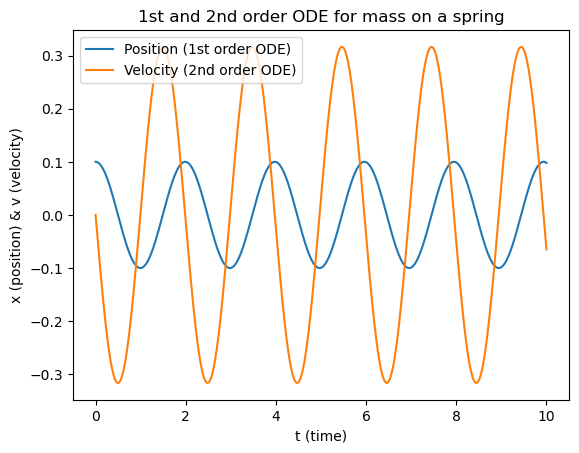

In [91]:
# Exercise 1
npts = 1000 # Number of points
tmax = 10 # Maximum time

# setting up the time array:
t = np.linspace(0.0, tmax, npts)

def f(y, t): # return derivatives of the array y
    k = 10.0
    m = 1.0
    return [ y[1], # the first equation dy[0]/dt 
            -(k/m)*y[0] # the second equation dy[1]/dt 
           ]

yinit = [0.1, 0] # TWO initial values, y and y'
y_odient = odeint(f, yinit , t)

plt.title("1st and 2nd order ODE for mass on a spring")
plt.plot(t, y_odient[:,0], label="Position (1st order ODE)")
plt.plot(t, y_odient[:,1], label="Velocity (2nd order ODE)")
plt.xlabel("t (time)")
plt.ylabel("x (position) & v (velocity)")
plt.legend()
plt.show()

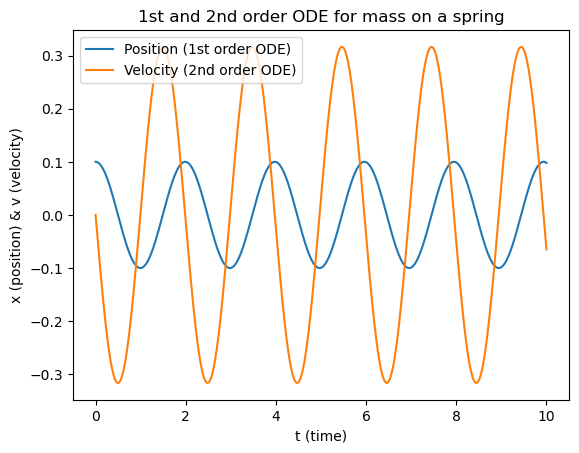

In [92]:
# Modified Code

npts = 1000 # Number of points
tmax = 10 # Maximum time

# setting up the time array:
t = np.linspace(0.0, tmax, npts)

# parameters
k=10
m=1

def f(y, t, k, m): # return derivatives of the array y
    return [ y[1], # the first equation dy[0]/dt 
            -(k/m)*y[0] # the second equation dy[1]/dt 
           ]

yinit = [0.1, 0] # TWO initial values, y and y'
y_odient = odeint(f, yinit , t, args=(k,m))

plt.title("1st and 2nd order ODE for mass on a spring")
plt.plot(t, y_odient[:,0], label="Position (1st order ODE)")
plt.plot(t, y_odient[:,1], label="Velocity (2nd order ODE)")
plt.xlabel("t (time)")
plt.ylabel("x (position) & v (velocity)")
plt.legend()
plt.show()

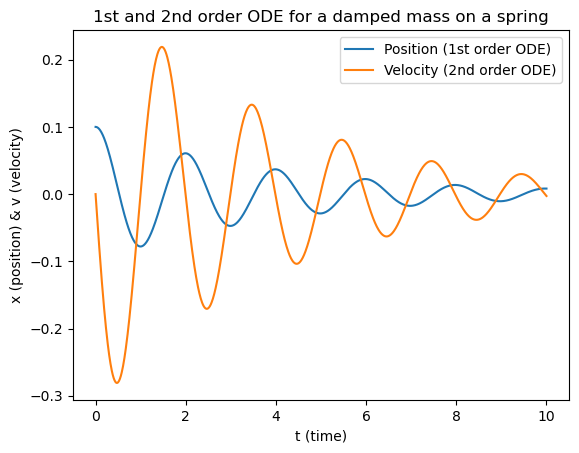

In [93]:
# Further Modified Code

npts = 1000 # Number of points
tmax = 10 # Maximum time

# setting up the time array:
t = np.linspace(0.0, tmax, npts)

# parameters
k=10
m=1
b=0.5

def f(y, t, k, m): # return derivatives of the array y
    return [ y[1], # the first equation dy[0]/dt 
            -((k/m)*y[0])-(b/m)*y[1] # the second equation dy[1]/dt 
           ]

yinit = [0.1, 0] # TWO initial values, y and y'
y_odient = odeint(f, yinit , t, args=(k,m))

plt.title("1st and 2nd order ODE for a damped mass on a spring")
plt.plot(t, y_odient[:,0], label="Position (1st order ODE)")
plt.plot(t, y_odient[:,1], label="Velocity (2nd order ODE)")
plt.xlabel("t (time)")
plt.ylabel("x (position) & v (velocity)")
plt.legend()
plt.show()

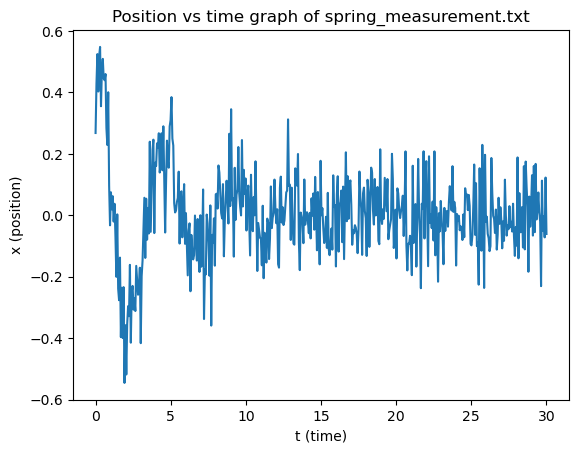

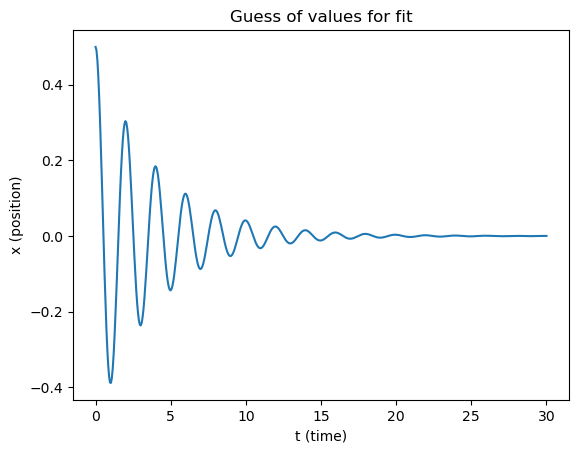

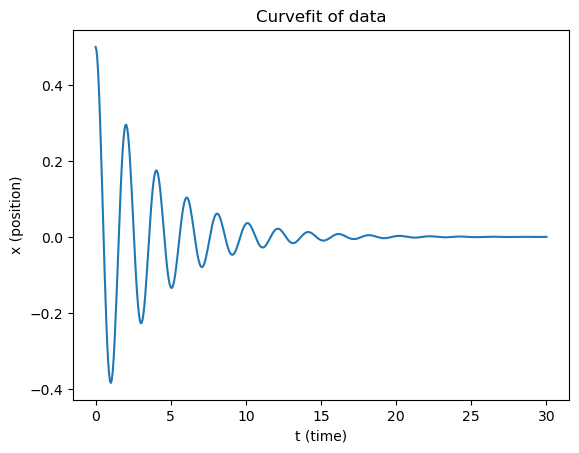

In [94]:
# Measuring spring constant
data=np.loadtxt("spring_measurement.txt", skiprows=1)
x_data=data[:,0]
y_data=data[:,1]

plt.title("Position vs time graph of spring_measurement.txt")
plt.plot(x_data, y_data)
plt.xlabel("t (time)")
plt.ylabel("x (position)")
plt.show()

# Curve Fit

def damped_spring_model(t,k,b):
    m=1
    y0=0.5
    v0=0
    y_int=[y0,v0]

    def f(y,t):
        return [y[1], -(k/m)*y[0]-(b/m)*y[1]]
    
    sol=odeint(f,y_int, t)
    return sol[:,0]

# Making Guesses
k_guess=10
b_guess=0.5
x_guess=damped_spring_model(x_data, k_guess, b_guess)

plt.title("Guess of values for fit")
plt.plot(x_data, x_guess)
plt.xlabel("t (time)")
plt.ylabel("x (position)")
plt.show()

# Return of the Curve fit
p0 = [k_guess, b_guess]

popt, pcov = curve_fit(damped_spring_model, x_data, y_data, p0=p0)

k_fit, b_fit = popt

y_fit = damped_spring_model(x_data, k_fit, b_fit)


# Plotting the curve fit
plt.plot(x_data, y_fit)
plt.title("Curvefit of data")
plt.xlabel("t (time)")
plt.ylabel("x (position)")
plt.show()

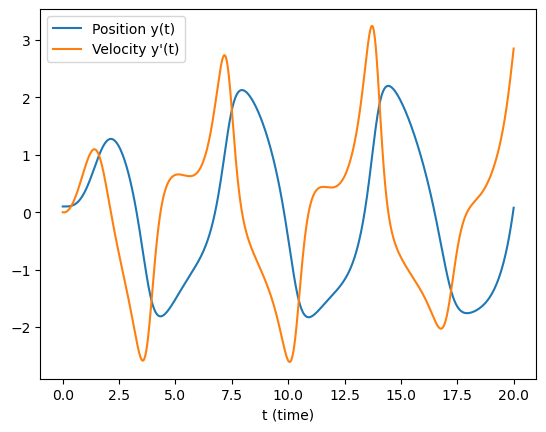

In [105]:
# Exercise 2

# Defining the fucntion

def f(y, t, A, m, w):
    y0, y1 = y
    dy0dt = y1
    dy1dt = m*(1 - y0**2)*y1 - y0 + A*np.sin(w*t)
    return [dy0dt, dy1dt]

# Initial conditions
yinit = [0.1, 0]  # y(0) and y'(0)

# Making an array for time
t = np.linspace(0, 20, 1000)

# parameterrs
A, m, w = 1.0, 1.0, 2.0

# Solve ODE
y_odient = odeint(f, yinit, t, args=(A, m, w))

# Plotting the graph
plt.plot(t, y_odient[:,0], label="Position y(t)")
plt.plot(t, y_odient[:,1], label="Velocity y'(t)")
plt.xlabel("t (time)")
plt.legend()
plt.show()
